## Volatility EWMA Estimators

**Finding an estimate for the volatility after previously concluding that constant volatility is not a valid assumption.**

In [9]:
# Importing Data
import pandas as pd

df = pd.read_excel("C:/Users/Aksha/OneDrive/Documents/GitHub/systematic-alpha-research/01_data-cleaning/Signal_Project_Data_Cleaned.xlsx", sheet_name = "Data")
df.head()

,Date,EDOLLAR,SP500,US10,LEANHOG,JPY,GOLD,WHEAT,NIKKEI,COPPER,BITCOIN
0,1984-03-23,71.84001,464.55,-33.070302,-5.24,0.012126,1145.9,857.50,NaN,NaN,NaN
1,1984-03-26,71.91001,464.65,-32.914052,-5.36,0.012139,1147.6,860.50,NaN,NaN,NaN
2,1984-03-27,71.89001,465.45,-32.976552,-4.79,0.012140,1146.4,859.75,NaN,NaN,NaN
3,1984-03-28,71.89001,467.70,-32.632802,-4.44,0.012153,1149.4,857.50,NaN,NaN,NaN
4,1984-03-29,71.86001,466.40,-32.445302,-4.56,0.012147,1148.9,858.25,NaN,NaN,NaN


## Estimate 0 - Constant Volatility

In [29]:
futures_vol1 = df[1:].diff().std()
print(futures_vol1)

futures_vol2_results = []
for col in df.columns[1:]:
    s = df[col].dropna().diff()
    futures_vol2_results.append((col,s.std()))
    futures_vol2 = pd.DataFrame(futures_vol2_results)

print(futures_vol2)

Date       0 days 19:11:53.163543235
EDOLLAR                       0.0742
SP500                      18.532178
US10                        0.433431
LEANHOG                     0.822816
JPY                         0.000059
GOLD                        9.956849
WHEAT                       8.752059
NIKKEI                    232.032758
COPPER                      0.042538
BITCOIN                   1155.88755
dtype: object
         0            1
0  EDOLLAR     0.074199
1    SP500    18.531262
2     US10     0.433412
3  LEANHOG     0.822776
4      JPY     0.000059
5     GOLD     9.956370
6    WHEAT     8.751677
7   NIKKEI   286.468982
8   COPPER     0.042538
9  BITCOIN  1155.887550


## Estimate 1 - Exponential Weighting

In [35]:
futures_diff = df.diff()
print(futures_diff)

vol_dict = {}
for col in df.columns[1:]:
    s = df[col].dropna().diff().dropna()
    vol_dict[col] = s.ewm(span=32).std().dropna()

exp_results = pd.DataFrame(vol_dict)  
print(exp_results)

        Date  EDOLLAR  SP500      US10  LEANHOG           JPY  GOLD  WHEAT  \
0        NaT      NaN    NaN       NaN      NaN           NaN   NaN    NaN   
1     3 days    0.070   0.10  0.156250   -0.120  1.300000e-05   1.7   3.00   
2     1 days   -0.020   0.80 -0.062500    0.570  1.000000e-06  -1.2  -0.75   
3     1 days    0.000   2.25  0.343750    0.350  1.300000e-05   3.0  -2.25   
4     1 days   -0.030  -1.30  0.187500   -0.120 -6.000000e-06  -0.5   0.75   
...      ...      ...    ...       ...      ...           ...   ...    ...   
10111 3 days    0.000   0.00  0.000000    0.000  0.000000e+00   0.0   0.00   
10112 1 days   -0.085 -12.25 -0.718750    1.075 -3.700000e-05  15.8  -2.00   
10113 1 days   -0.075 -45.75 -0.296875    0.125 -5.100000e-05  -9.8  11.75   
10114 1 days    0.045  59.00  0.000000   -0.875  7.700000e-05   9.9   0.00   
10115 1 days   -0.065   0.00  0.000000   -0.175  6.200000e-05   0.4   0.00   

       NIKKEI  COPPER  BITCOIN  
0         NaN     NaN      NaN

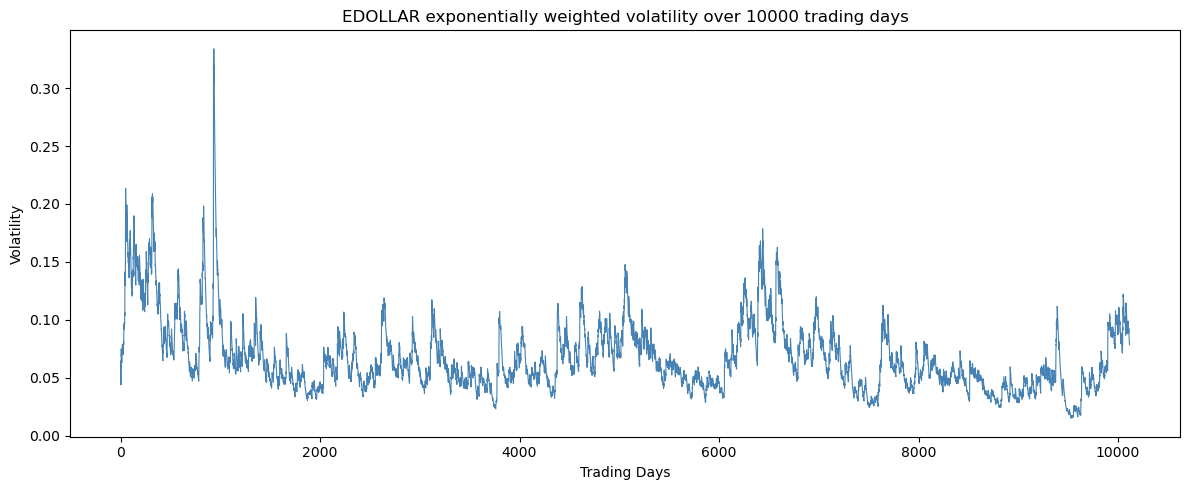

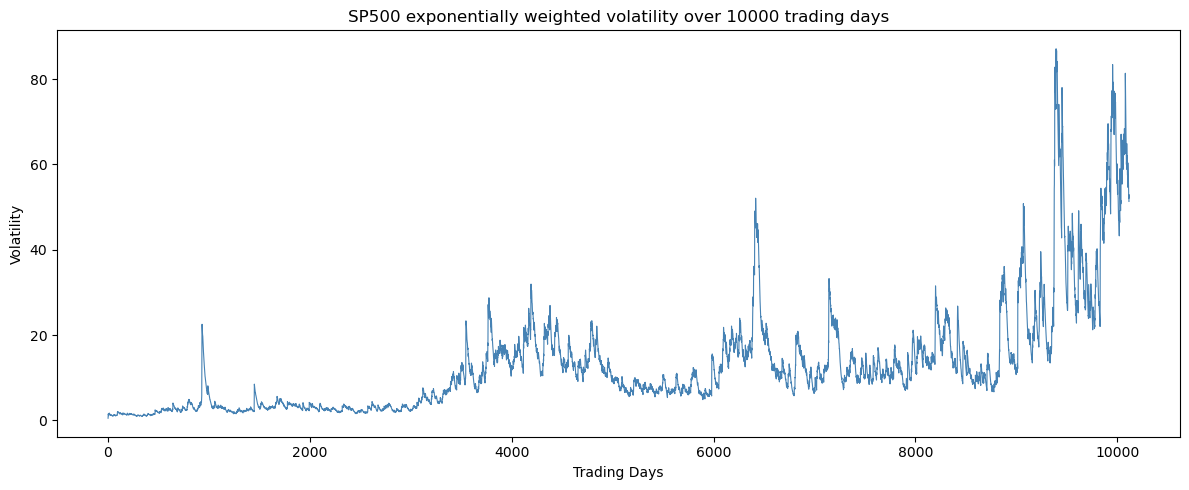

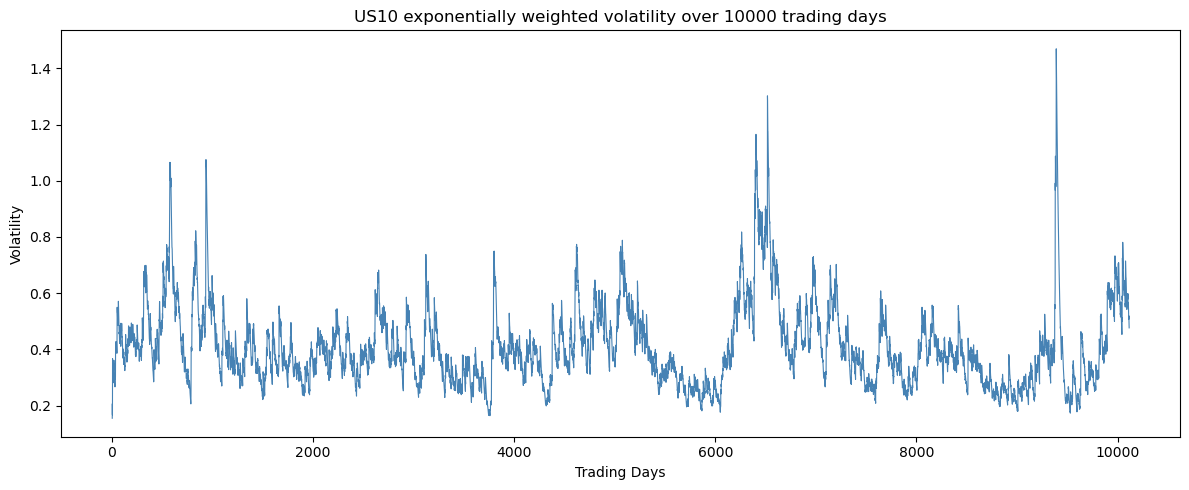

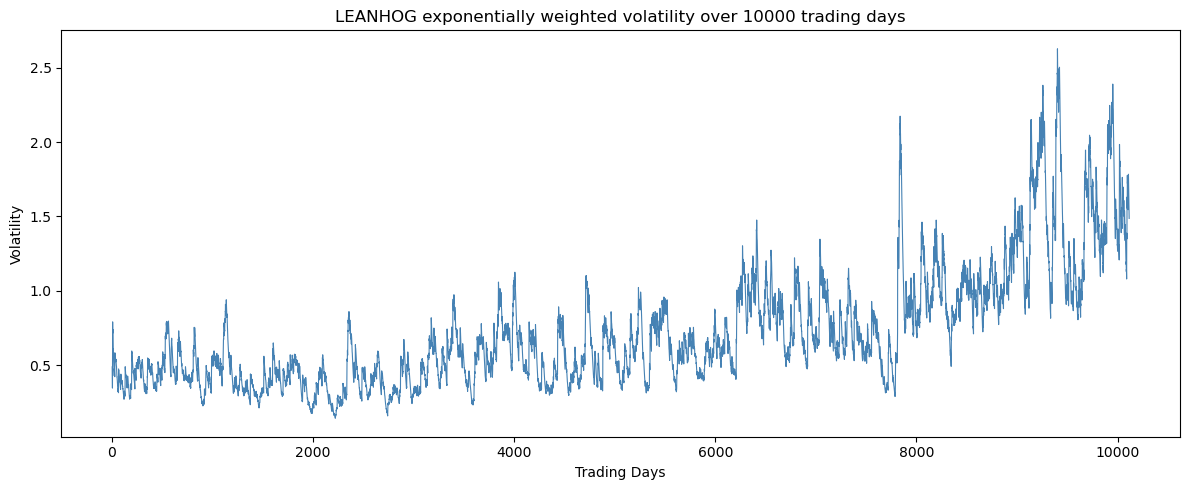

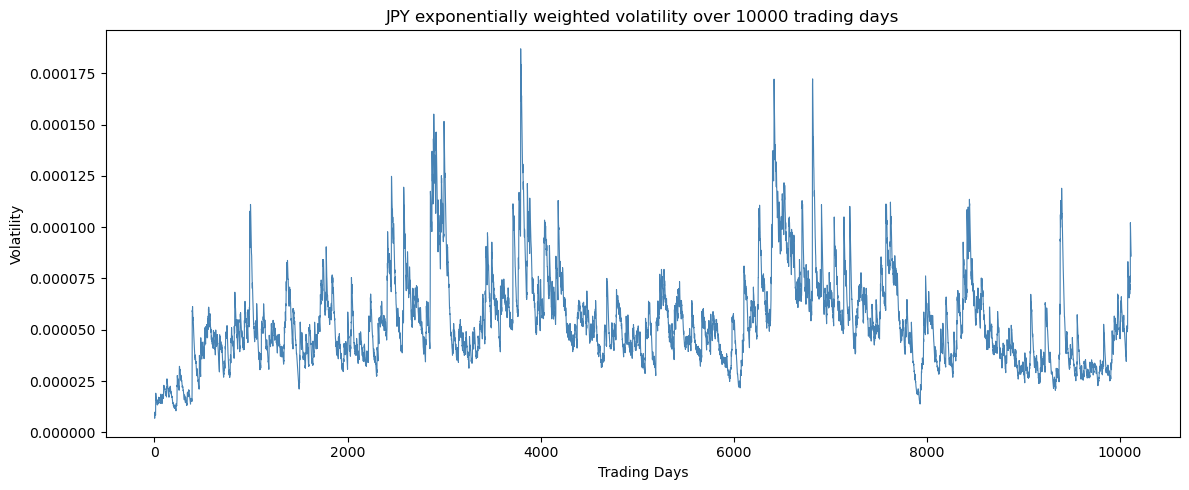

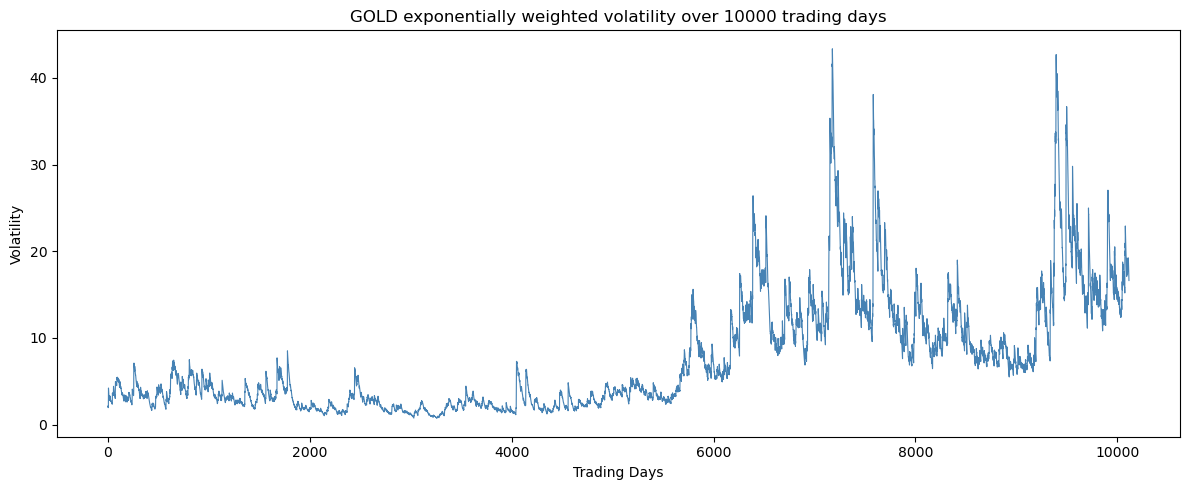

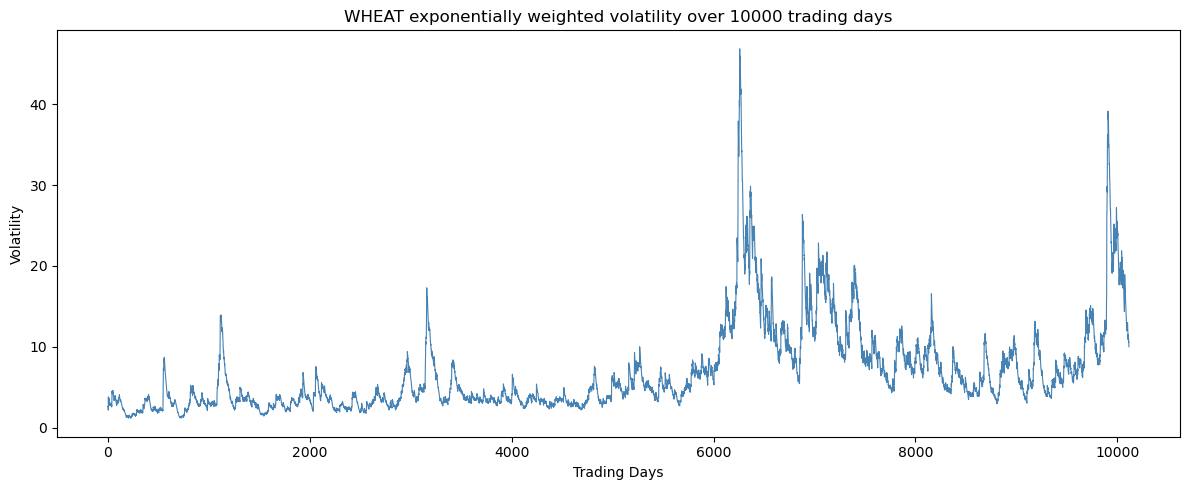

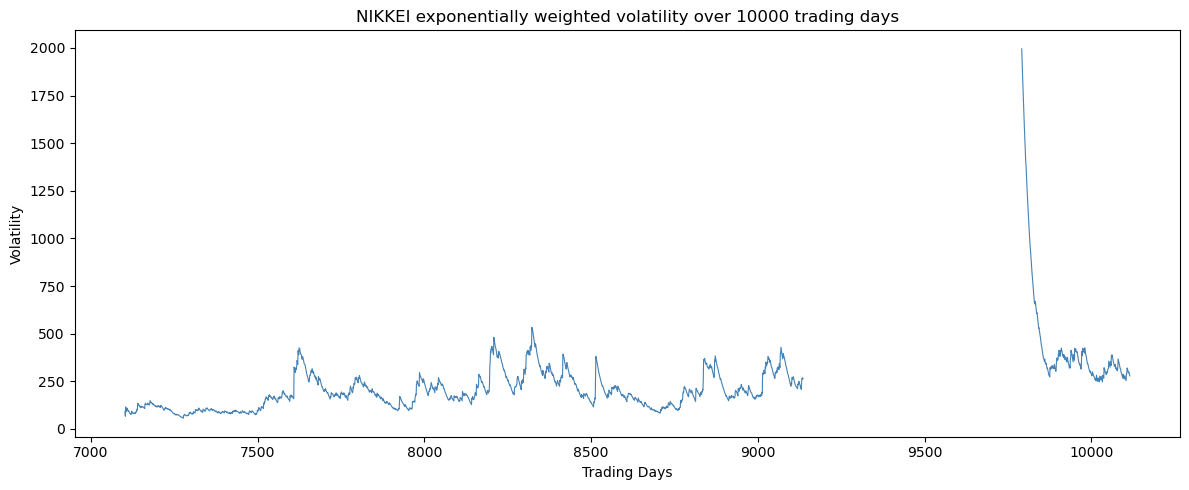

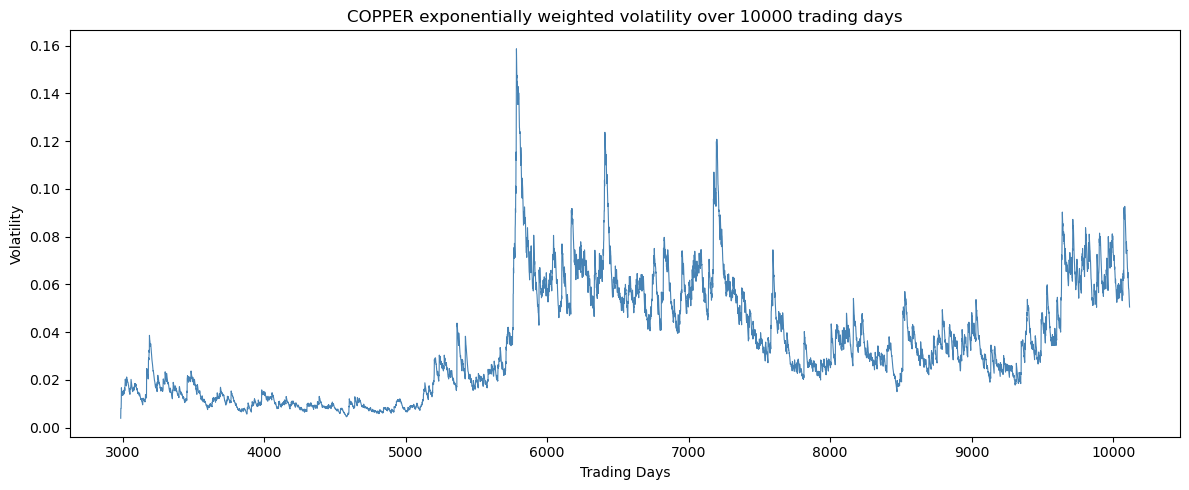

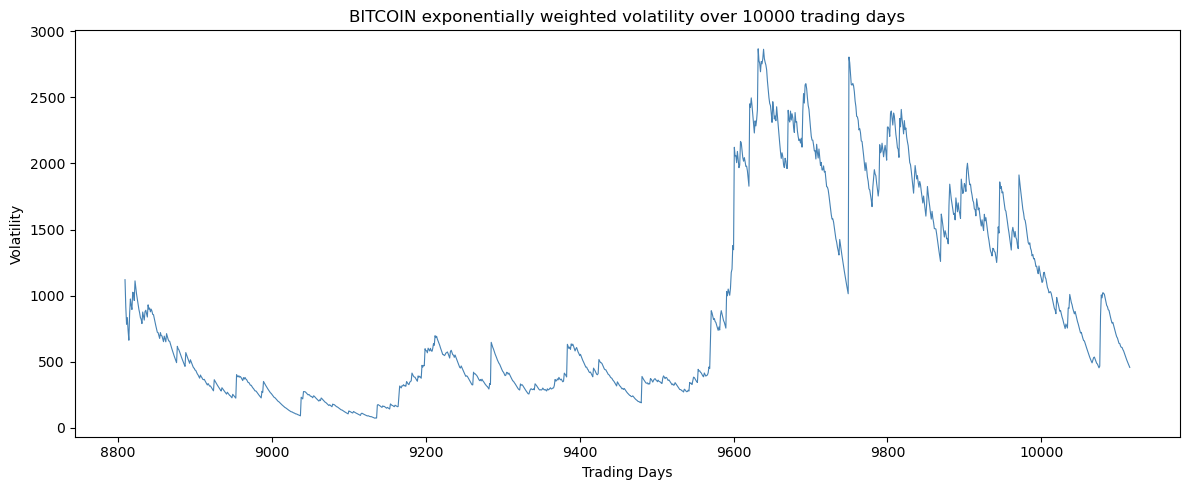

In [43]:
import matplotlib.pyplot as plt
import numpy as np

for col in exp_results:
    plt.figure(figsize=(12,5))
    plt.plot(exp_results[col], linewidth = 0.8, color = "steelblue", label = f"{col}")
    plt.title(f"{col} exponentially weighted volatility over 10000 trading days")
    plt.ylabel("Volatility")
    plt.xlabel("Trading Days")
    plt.tight_layout()
    plt.show()

## Estimate 2 - Exponential Weighting with Fast/Slow Averages

In [44]:
def compute_ewma_vol(price_series, fast_span=32, slow_window=2560, blend_fast=0.7, blend_slow=0.3, min_obs=60):
    diffs = price_series.diff()

    # Fast Component
    fast_vol = diffs.ewm(span=fast_span, min_periods=min_obs).std()
    
    # Slow component
    slow_vol = diffs.ewm(span=slow_window, min_periods=min_obs).std()
    
    blended_vol = blend_fast * fast_vol + blend_slow * slow_vol

    return blended_vol

vol_dict2 = {}
for col in df.columns[1:]:
    s = df[col].dropna().diff().dropna()
    vol_dict2[col] = compute_ewma_vol(s).dropna()

exp_results2 = pd.DataFrame(vol_dict2)  
print(exp_results2)

        EDOLLAR      SP500      US10   LEANHOG       JPY       GOLD  \
1           NaN        NaN       NaN       NaN       NaN        NaN   
2           NaN        NaN       NaN       NaN       NaN        NaN   
3           NaN        NaN       NaN       NaN       NaN        NaN   
4           NaN        NaN       NaN       NaN       NaN        NaN   
5           NaN        NaN       NaN       NaN       NaN        NaN   
...         ...        ...       ...       ...       ...        ...   
10111  0.098796  70.348321  0.661655  2.200425  0.000123  26.225469   
10112  0.098024  68.701133  0.662956  2.159794  0.000120  25.813932   
10113  0.095843  67.368555  0.654887  2.119211  0.000117  25.762672   
10114  0.096899  68.991823  0.643443  2.079909  0.000117  25.497370   
10115  0.097373  68.446197  0.629283  2.038075  0.000114  24.995246   

           WHEAT      NIKKEI    COPPER      BITCOIN  
1            NaN         NaN       NaN          NaN  
2            NaN         NaN       NaN 

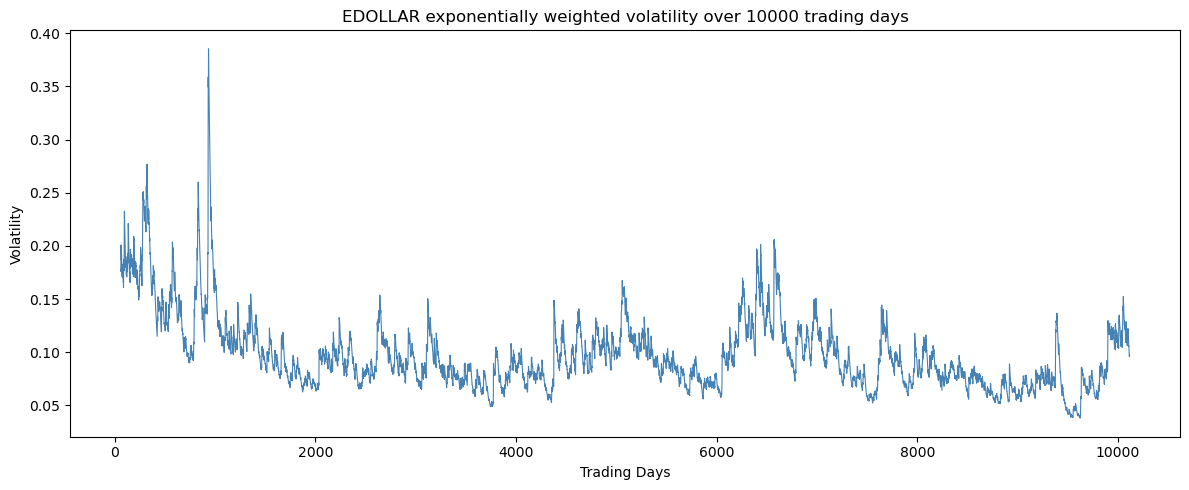

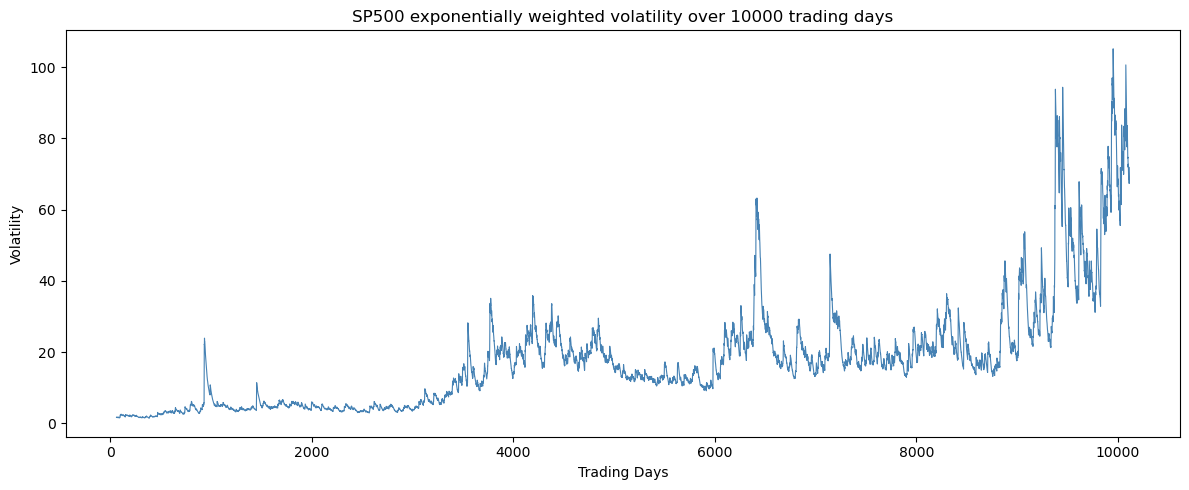

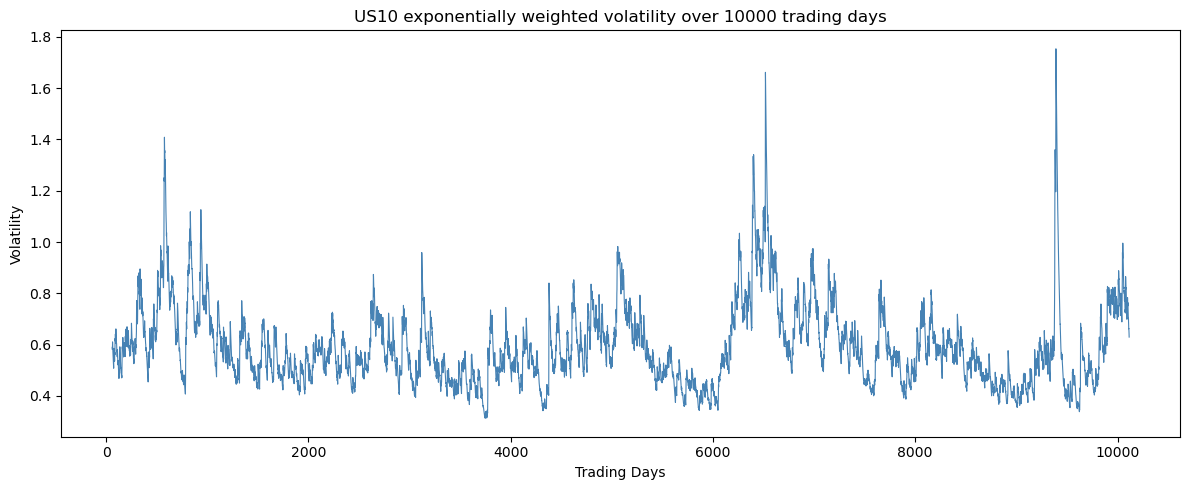

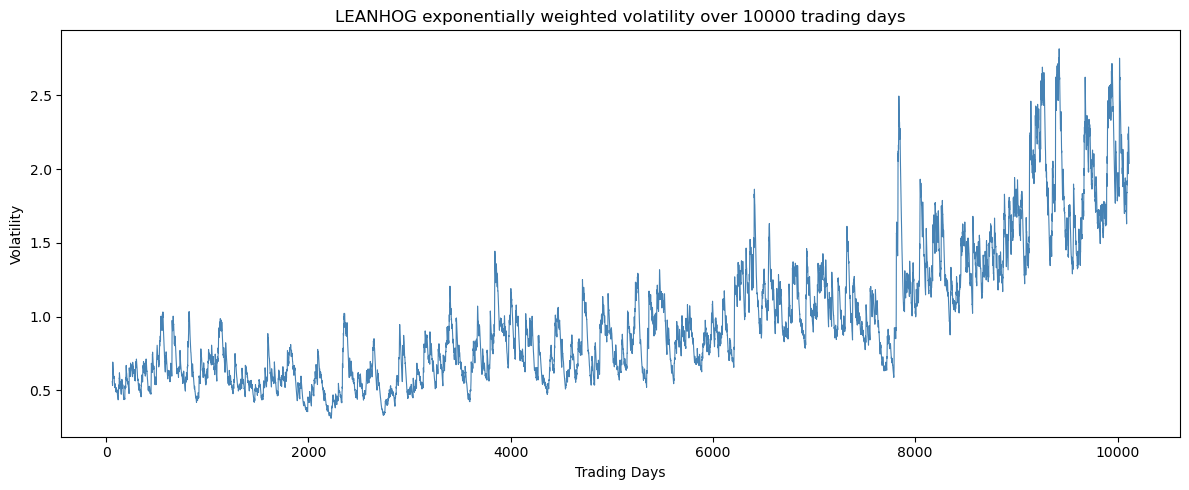

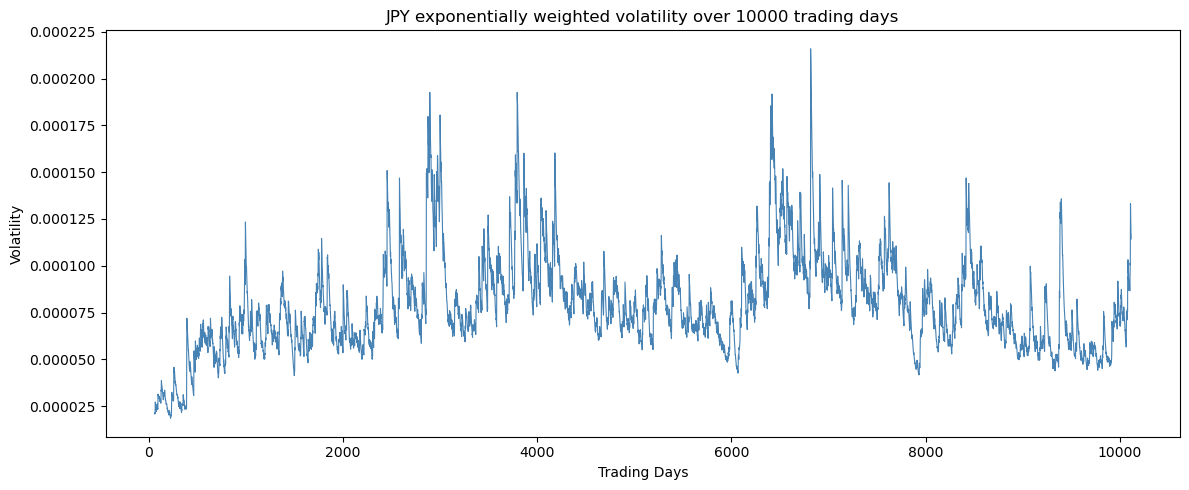

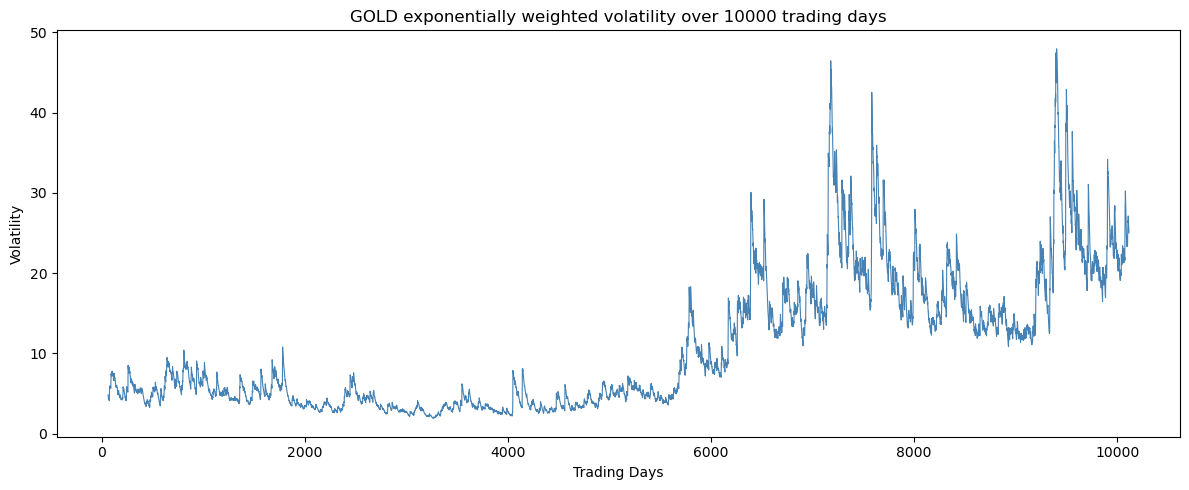

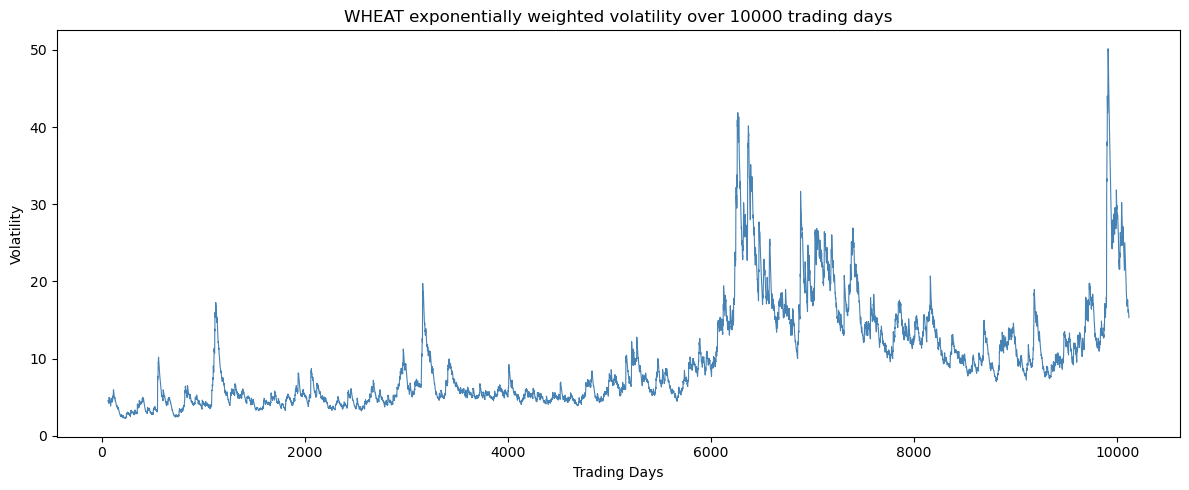

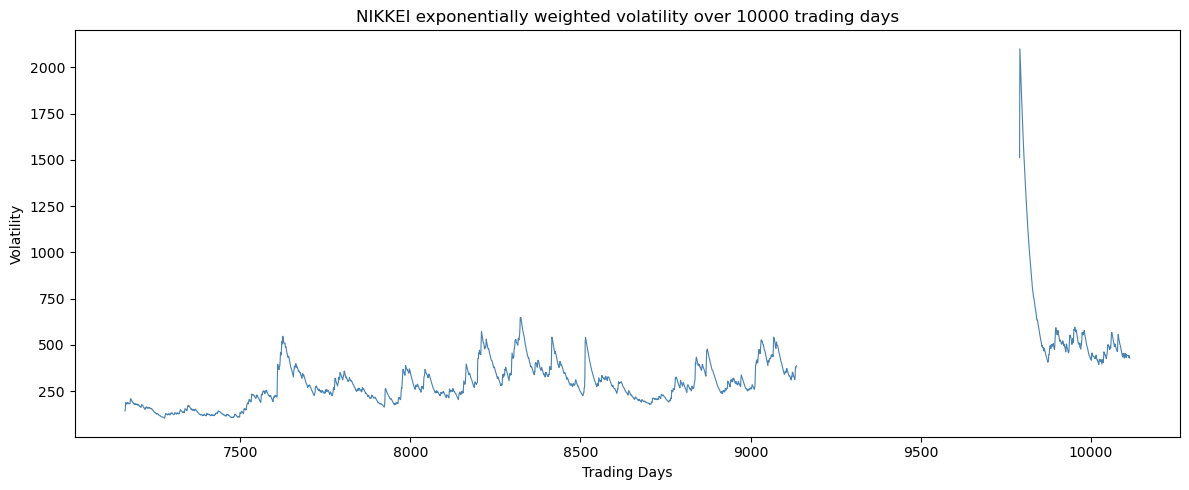

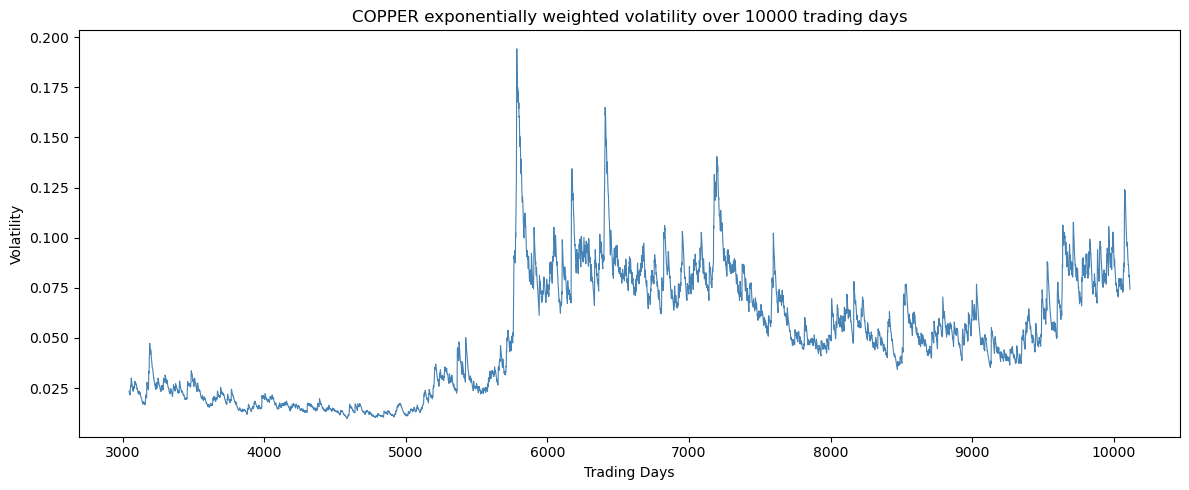

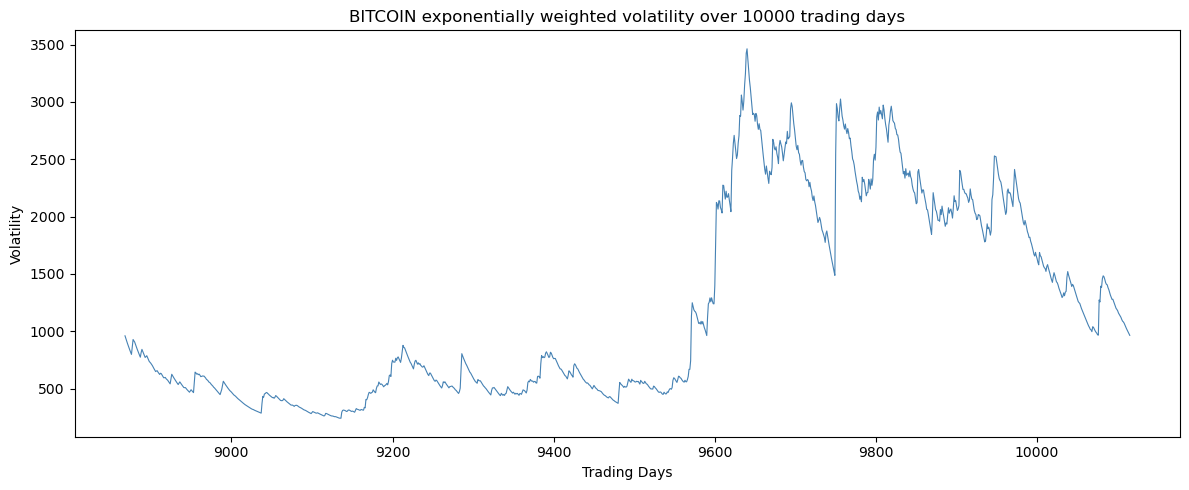

In [45]:
for col in exp_results2:
    plt.figure(figsize=(12,5))
    plt.plot(exp_results2[col], linewidth = 0.8, color = "steelblue", label = f"{col}")
    plt.title(f"{col} exponentially weighted volatility over 10000 trading days")
    plt.ylabel("Volatility")
    plt.xlabel("Trading Days")
    plt.tight_layout()
    plt.show()